# Installing libraries

In [2]:
!pip install ultralytics --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 984.0/984.0 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 40.9 MB/s eta 0:00:00


In [3]:
## 1. Install and Import Libraries


import torch
import torchvision.transforms as transforms
from PIL import Image, ImageDraw
from ultralytics import YOLO
from google.colab import files
import os
from IPython.display import display, Image as IPImage
import zipfile
import shutil
import random
import re
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

from PIL import Image




print("✅ Libraries ready!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries ready!


In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


#  YOLO Training

Below steps were for creating the yolo detector (training etc) ready

In [ ]:
##  2. Upload Your Dataset Zip

uploaded = files.upload()
zip_path = '/content/cropped_yolo_prev_yolo.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/real_signs_final')

print(" Extracted to /content/real_signs_final")


Saving labelledyolo70images.zip to labelledyolo70images (1).zip
✅ Extracted to /content/real_signs_final


In [ ]:

##  3. List and Explore Extracted Files

print(os.listdir('/content/real_signs_final'))

['labels_yolotrainset_2025-04-09-01-26-27']


In [ ]:
##  4. If files are inside a subfolder, move them up

src_folder = '/content/real_signs_final/labels_yolotrainset_2025-04-09-01-26-27'
dst_folder = '/content/real_signs_final'

for filename in os.listdir(src_folder):
    src_file = os.path.join(src_folder, filename)
    dst_file = os.path.join(dst_folder, filename)
    if os.path.exists(dst_file):
        os.remove(dst_file)
    shutil.move(src_file, dst_folder)

print(" All files moved successfully!")

os.rmdir(src_folder)
print(" Cleaned up empty folder!")

✅ All files moved successfully!
✅ Cleaned up empty folder!


In [ ]:
##  5. Clean Filenames (remove spaces, weird characters)

folder_path = '/content/real_signs_final'

for filename in os.listdir(folder_path):
    clean_name = filename.lower().replace(' ', '_').replace('#', '_')
    clean_name = re.sub(r'[^a-z0-9_.]', '', clean_name)
    old_path = os.path.join(folder_path, filename)
    new_path = os.path.join(folder_path, clean_name)
    os.rename(old_path, new_path)

print("Filenames cleaned!")

✅ Filenames cleaned!


In [ ]:

##  6. Create `data.yaml` File for YOLOv8

yaml_content = """
train: /content/real_signs_final
val: /content/real_signs_final

nc: 1
names: ['traffic_sign']
"""

with open('/content/real_signs_final/data.yaml', 'w') as f:
    f.write(yaml_content)

print(" data.yaml created!")

✅ data.yaml created!


In [ ]:
##  7. Start YOLOv8 Training

from ultralytics import YOLO

# Load YOLOv8 nano model
model = YOLO('yolov8n.pt')

# Start training
model.train(
    data='/content/real_signs_final/data.yaml',
    imgsz=640,
    epochs=100,
    batch=8,
    name='yolov8n_traffic_signs_real'
)

print("Training started!")

100%|██████████| 6.25M/6.25M [00:00<00:00, 105MB/s]


Ultralytics 8.3.105 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/real_signs_final/data.yaml, epochs=100, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolov8n_traffic_signs_real, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True

100%|██████████| 755k/755k [00:00<00:00, 17.2MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 83.8MB/s]


...

    100/100      1.55G     0.3975     0.4251     0.8379          2        640: 100%|██████████| 10/10 [00:01<00:00,  8.02it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:00<00:00, 10.77it/s]

                   all         75        100      0.999          1      0.995       0.93



100 epochs completed in 0.064 hours.
Optimizer stripped from runs/detect/yolov8n_traffic_signs_real/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/yolov8n_traffic_signs_real/weights/best.pt, 6.3MB

Validating runs/detect/yolov8n_traffic_signs_real/weights/best.pt...
Ultralytics 8.3.105 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  3.40it/s]


                   all         75        100      0.999          1      0.995       0.94
Speed: 0.4ms preprocess, 4.2ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to runs/detect/yolov8n_traffic_signs_real
🚀 Training started!


In [ ]:

##  8. After Training (Optional): Save Weights to Google Drive

from google.colab import drive

drive.mount('/content/drive')

!cp /content/runs/detect/yolov8n_traffic_signs_real/weights/best.pt /content/drive/MyDrive/

print(" Model weights saved to Drive!")

Mounted at /content/drive
✅ Model weights saved to Drive!


In [ ]:
!cp /content/runs/detect/yolov8n_traffic_signs_real3/weights/best.pt /content/drive/MyDrive/
print("✅ Freshly trained model saved to Drive!")


cp: cannot stat '/content/runs/detect/yolov8n_traffic_signs_real3/weights/best.pt': No such file or directory
✅ Freshly trained model saved to Drive!


#Run these to use the YOLO sign detector with CNN, followed by LIME (XAI)

In [5]:
#2. Load trained YOLO detector
detector = YOLO('/content/best.pt')
#detector = YOLO('/content/drive/MyDrive/Additional Testing Material Traffic Sign Recognition/YOLOv8_Weights/best.pt')


In [6]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [7]:
root_dir = '/content/gtsrb_path'  # Replace with the actual path to your GTSRB dataset

In [8]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.3403, 0.3121, 0.3214), (0.2724, 0.2608, 0.2669))
])

# Download and load training data
train_data = torchvision.datasets.GTSRB(root='/content/gtsrb_path', split='train', transform=transform, download=True)
test_data = torchvision.datasets.GTSRB(root='/content/gtsrb_path', split='test', transform=transform, download=True)

# Data loaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


100%|██████████| 187M/187M [00:24<00:00, 7.79MB/s]
100%|██████████| 89.0M/89.0M [00:11<00:00, 7.80MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 207kB/s]


In [9]:
#4 conv layers
class TrafficSignCNN(nn.Module):
    def __init__(self):
        super(TrafficSignCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*3*3, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 43)  # 43 output classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize model
vanilla_model = TrafficSignCNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vanilla_model.to(device)


TrafficSignCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=1024, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=43, bias=T

In [10]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [11]:
four_conv_model = TrafficSignCNN()
four_conv_model.load_state_dict(torch.load('/content/gtsrb_4conv.pth', map_location=device))
#four_conv_model.load_state_dict(torch.load('/content/drive/MyDrive/Additional Testing Material Traffic Sign Recognition/Model_weights/4 Conv model/gtsrb_4conv.pth', map_location=device))
four_conv_model = four_conv_model.to(device)
four_conv_model.eval()

TrafficSignCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=1024, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=43, bias=T

In [12]:
#  4. Define transforms
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

id_to_label = {  # (same id to label mapping)
    0: "Speed limit (20km/h)", 1: "Speed limit (30km/h)", 2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)", 4: "Speed limit (70km/h)", 5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)", 7: "Speed limit (100km/h)", 8: "Speed limit (120km/h)",
    9: "No passing", 10: "No passing for vehicles over 3.5 metric tons", 11: "Right-of-way at the next intersection",
    12: "Priority road", 13: "Yield", 14: "Stop", 15: "No vehicles",
    16: "Vehicles over 3.5 metric tons prohibited", 17: "No entry", 18: "General caution",
    19: "Dangerous curve to the left", 20: "Dangerous curve to the right", 21: "Double curve",
    22: "Bumpy road", 23: "Slippery road", 24: "Road narrows on the right",
    25: "Road work", 26: "Traffic signals", 27: "Pedestrians", 28: "Children crossing",
    29: "Bicycles crossing", 30: "Beware of ice/snow", 31: "Wild animals crossing",
    32: "End of all speed and passing limits", 33: "Turn right ahead", 34: "Turn left ahead",
    35: "Ahead only", 36: "Go straight or right", 37: "Go straight or left",
    38: "Keep right", 39: "Keep left", 40: "Roundabout mandatory",
    41: "End of no passing", 42: "End of no passing by vehicles over 3.5 metric tons"
}

In [11]:
#  5. Upload a test image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Saving 50#2.jpg to 50#2.jpg


In [12]:
#  6. Detection
results = detector.predict(source=image_path, conf=0.1, save=True)


image 1/1 /content/50#2.jpg: 512x640 1 traffic_sign, 37.4ms
Speed: 13.3ms preprocess, 37.4ms inference, 345.1ms postprocess per image at shape (1, 3, 512, 640)
Results saved to runs/detect/predict


Cropped Image 0 (Confidence 0.95):


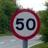

In [13]:
#  7. Cropping
padding = 10
boxes = results[0].boxes.xyxy.cpu().numpy()
scores = results[0].boxes.conf.cpu().numpy()
original_image = Image.open(image_path).convert('RGB')

cropped_images = []

for idx, (box, score) in enumerate(zip(boxes, scores)):
    if score < 0.3:
        continue
    x1, y1, x2, y2 = map(int, box)
    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(original_image.width, x2 + padding)
    y2 = min(original_image.height, y2 + padding)

    cropped_img = original_image.crop((x1, y1, x2, y2))
    cropped_img = cropped_img.resize((48, 48))
    crop_path = f'/content/crop_real_{idx}.jpg'
    cropped_img.save(crop_path)
    cropped_images.append(crop_path)

    print(f"Cropped Image {idx} (Confidence {score:.2f}):")
    display(IPImage(filename=crop_path))


In [14]:
#  8. Classify Cropped Signs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # ensure device defined

if len(cropped_images) == 0:
    print(" No traffic signs detected!")
else:
    print(f" Classifying {len(cropped_images)} cropped signs:")
    for img_path in cropped_images:
        img = Image.open(img_path).convert('RGB')
        img = transform(img).unsqueeze(0).to(device)   # 🛠️ move the image to same device
        outputs = four_conv_model(img)                       # vgg
        _, predicted = torch.max(outputs, 1)
        label = id_to_label.get(predicted.item(), "Unknown Sign")
        print(f" Prediction for {img_path}: {label}")


 Classifying 1 cropped signs:
 Prediction for /content/crop_real_0.jpg: Speed limit (50km/h)


Printing examples from the training set for reference


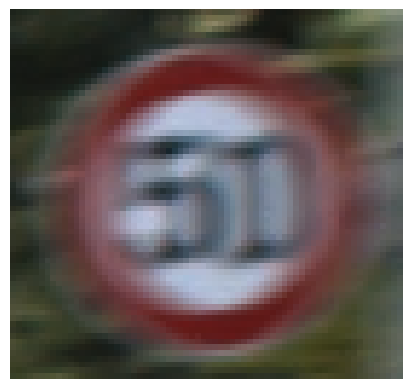

In [15]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Path to class 22 folder
class_folder = '/content/gtsrb_path/gtsrb/GTSRB/Training/00002'

# List all image files
image_files = os.listdir(class_folder)

# Pick the first image (or you can randomly pick)
img_path = os.path.join(class_folder, image_files[0])

# Open and display
img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')
plt.show()


Explainability using LIME

In [ ]:
!pip install lime shap --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


  0%|          | 0/3000 [00:00<?, ?it/s]

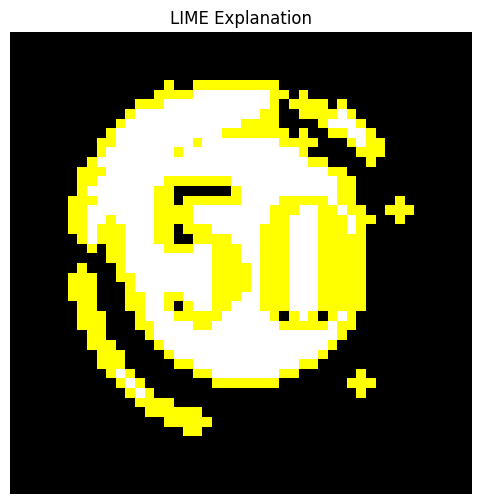

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
from skimage.segmentation import quickshift


# 1. Define a prediction function for LIME
def predict_fn(images):
    images = torch.stack([transform(Image.fromarray(img)).to(device) for img in images], dim=0)
    outputs = four_conv_model(images)
    probs = torch.nn.functional.softmax(outputs, dim=1)
    return probs.detach().cpu().numpy()

# # 2. Choose an image from your dataset
# image, label = test_data[42]  # Random sample
# img_np = (image.permute(1,2,0).numpy() * 255).astype('uint8')  # Convert to numpy
# 2. Load uploaded image and preprocess for LIME
# image = Image.open(image_path).convert('RGB').resize((48, 48))
# img_np = np.array(image)
# one of the cropped images from your YOLO detector output
lime_image_path = cropped_images[0]  # or any index like [1], [2], etc.

# Load and prepare the image for LIME
image = Image.open(lime_image_path).convert('RGB')  # already 48x48
img_np = np.array(image)  # convert to numpy for LIME


# 3. Create LIME explainer
explainer = lime_image.LimeImageExplainer()

# 4. Explain prediction
explanation = explainer.explain_instance(
    img_np,
    predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=3000,
    segmentation_fn=quickshift
)

# 5. Show explanation
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    hide_rest=True
)

plt.figure(figsize=(6,6))
plt.title("LIME Explanation")
plt.imshow(mark_boundaries(temp, mask))
plt.axis('off')
plt.show()


In [ ]:
from ultralytics import YOLO

# Load your trained YOLO model
model = YOLO('/content/best.pt')  #

# Predict
results = model.predict(img, conf=0.3)  # You can adjust conf threshold



0: 640x480 1 traffic_sign, 19.1ms
Speed: 5.2ms preprocess, 19.1ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)


In [ ]:
# Results object
boxes = results[0].boxes  # first image's detections

for box in boxes:
    # Get bounding box coordinates
    x1, y1, x2, y2 = box.xyxy[0]  # bounding box
    conf = box.conf[0]  # confidence
    cls = int(box.cls[0])  # class index

    # Draw rectangle
    img = cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (255,0,0), 2)

    # Put class and confidence
    label = f"{cls} {conf:.2f}"
    img = cv2.putText(img, label, (int(x1), int(y1)-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)


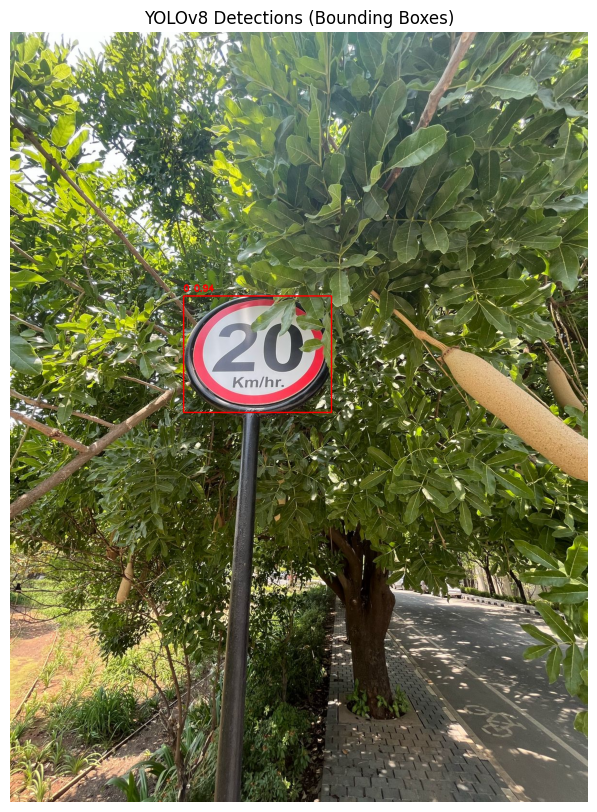

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.title("YOLOv8 Detections (Bounding Boxes)")
plt.show()


#**Full model in one code**

The previous section runs the code part by part, but to just run it in one go, run this block and then upload your test images

In [ ]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import torch
import torchvision.transforms as transforms
from ultralytics import YOLO

# Load YOLO detector model
detector = YOLO('/content/best.pt')

# 📦 Brightness Enhancer Function
from PIL import ImageEnhance

def enhance_brightness(image, factor=1.5):  # factor > 1 brightens, <1 darkens
    enhancer = ImageEnhance.Brightness(image)
    return enhancer.enhance(factor)


# Define your 4-CONV Traffic Sign CNN
class TrafficSignCNN(torch.nn.Module):
    def __init__(self):
        super(TrafficSignCNN, self).__init__()
        self.conv_layers = torch.nn.Sequential(
            torch.nn.Conv2d(3, 64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),

            torch.nn.Conv2d(64, 128, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),

            torch.nn.Conv2d(128, 256, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),

            torch.nn.Conv2d(256, 512, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2)
        )
        self.fc_layers = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(512 * 3 * 3, 1024),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(1024, 43)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Load CNN model
cnn_model = TrafficSignCNN()
cnn_model.load_state_dict(torch.load('/content/gtsrb_4conv.pth', map_location=torch.device('cpu')))
cnn_model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn_model.to(device)

transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ID to label mapping
id_to_label = {    0: "Speed limit (20km/h)", 1: "Speed limit (30km/h)", 2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)", 4: "Speed limit (70km/h)", 5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)", 7: "Speed limit (100km/h)", 8: "Speed limit (120km/h)",
    9: "No passing", 10: "No passing for vehicles over 3.5 metric tons", 11: "Right-of-way at the next intersection",
    12: "Priority road", 13: "Yield", 14: "Stop", 15: "No vehicles",
    16: "Vehicles over 3.5 metric tons prohibited", 17: "No entry", 18: "General caution",
    19: "Dangerous curve to the left", 20: "Dangerous curve to the right", 21: "Double curve",
    22: "Bumpy road", 23: "Slippery road", 24: "Road narrows on the right",
    25: "Road work", 26: "Traffic signals", 27: "Pedestrians", 28: "Children crossing",
    29: "Bicycles crossing", 30: "Beware of ice/snow", 31: "Wild animals crossing",
    32: "End of all speed and passing limits", 33: "Turn right ahead", 34: "Turn left ahead",
    35: "Ahead only", 36: "Go straight or right", 37: "Go straight or left",
    38: "Keep right", 39: "Keep left", 40: "Roundabout mandatory",
    41: "End of no passing", 42: "End of no passing by vehicles over 3.5 metric tons"}

# Smart Full Pipeline
def smart_pipeline(image_path):
    img = Image.open(image_path).convert('RGB')
    width, height = img.size

    # Display original image
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Original Image")
    plt.show()

    # Decide cropped vs full
    if width <= 128 and height <= 128 and abs(width - height) < 10:
        print("Cropped Image Detected - Skipping YOLO...")

        bright_img = enhance_brightness(img, factor=1.5)
        img_trans = transform(bright_img).unsqueeze(0).to(device)
        outputs = cnn_model(img_trans)
        _, predicted = torch.max(outputs, 1)

        print(f" Predicted Class Number: {predicted.item()}")
        print(f"Predicted Class Label: {id_to_label[predicted.item()]}")

        plt.figure(figsize=(3,3))
        plt.imshow(bright_img)
        plt.axis('off')
        plt.title(f"Class: {id_to_label[predicted.item()]}")
        plt.show()

    else:
        print("Full Scene Detected - Running YOLO...")
        results = detector.predict(image_path, conf=0.2)
        boxes = results[0].boxes

        if not boxes:
            print("No signs detected by YOLO.")

        for idx, box in enumerate(boxes):
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = box.conf[0]

            if conf > 0.65:
                crop = img.crop((x1, y1, x2, y2)).resize((48, 48))
                bright_crop = enhance_brightness(crop, factor=1.6)  # Brighten cropped image


                img_trans = transform(bright_crop).unsqueeze(0).to(device)
                outputs = cnn_model(img_trans)
                _, predicted = torch.max(outputs, 1)

                print(f"Detected Sign {idx+1}:")
                print(f"Class Number: {predicted.item()}")
                print(f"Class Label: {id_to_label[predicted.item()]}")

                plt.figure(figsize=(3,3))
                plt.imshow(bright_crop)
                plt.axis('off')
                plt.title(f"Sign {idx+1}: {id_to_label[predicted.item()]}")
                plt.show()


                plt.figure(figsize=(6,3))
                plt.subplot(1, 2, 1)
                plt.imshow(crop)
                plt.title("Original Crop")
                plt.axis('off')

                bright_crop = enhance_brightness(crop, 1.6)
                plt.subplot(1, 2, 2)
                plt.imshow(bright_crop)
                plt.title("Brightened")
                plt.axis('off')
                plt.show()



# **Uploading an image to run through the full pipeline**

Saving d1.jpg to d1.jpg


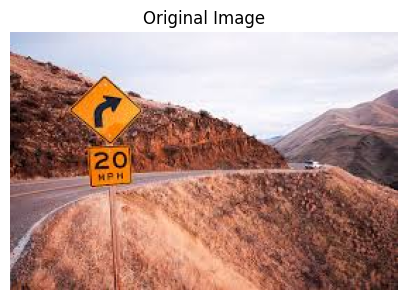

Full Scene Detected - Running YOLO...

image 1/1 /content/d1.jpg: 448x640 2 traffic_signs, 16.6ms
Speed: 2.9ms preprocess, 16.6ms inference, 5.0ms postprocess per image at shape (1, 3, 448, 640)
Detected Sign 1:
Class Number: 20
Class Label: Dangerous curve to the right


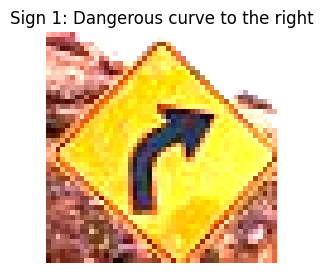

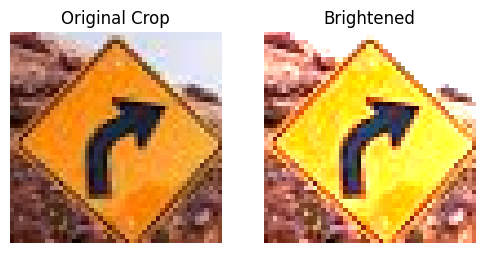

Detected Sign 2:
Class Number: 2
Class Label: Speed limit (50km/h)


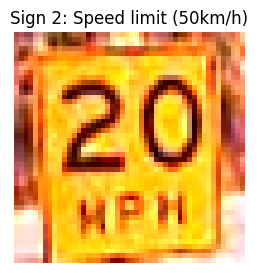

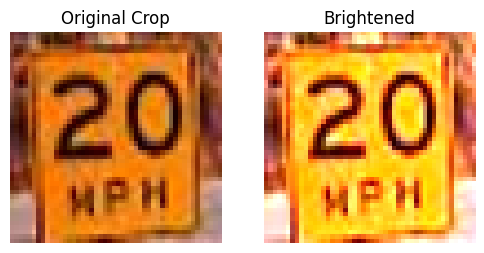

In [ ]:
# Upload a test image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

smart_pipeline(image_path)

To test on an image already loaded/ from the GTSRB train/test set

In [ ]:

# Define transformations
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.3403, 0.3121, 0.3214), (0.2724, 0.2608, 0.2669))
])

# Download and load training data
train_data = torchvision.datasets.GTSRB(root='/content/gtsrb_path', split='train', transform=transform, download=True)
test_data = torchvision.datasets.GTSRB(root='/content/gtsrb_path', split='test', transform=transform, download=True)

# Data loaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


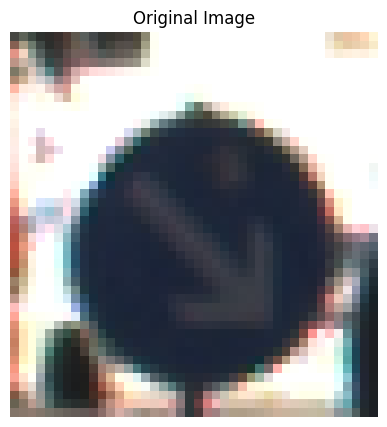

Cropped Image Detected - Skipping YOLO...
Predicted Class Number: 38
Predicted Class Label: Keep right


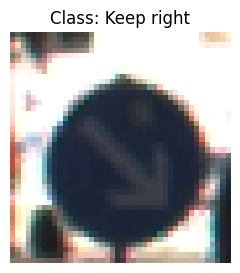

In [ ]:
smart_pipeline('/content/gtsrb_path/gtsrb/GTSRB/Training/00038/00002_00012.ppm')
